Project code

In [5]:
import json

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import pathlib
from sklearn.datasets import load_files
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import load_files
from collections import Counter

## Preprocessing for NERC dataset

In [6]:
cwd = pathlib.Path.cwd()
nerc_folder = cwd.joinpath('nerc_conll2003')
print('path:', nerc_folder)

path: /Users/robertostoica/Desktop/University_files_(year_3)_extra/period_4/Text Mining for AI/Assignments/Lab_Assignments/project/nerc_conll2003


In [7]:
file_name = ('eng.train')
file_path = f"{nerc_folder}/{file_name}"

training_features = []
training_gold_labels = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        # Skip empty lines (sentence separators)
        if line.strip():
            parts = line.strip().split()
            if len(parts) == 4:  # Ensuring the correct number of columns
                word, pos, chunk, ne_label = parts

                # Skip "-DOCSTART-" entries
                if word != "-DOCSTART-":
                    feature_dict = {
                        "words": word,
                        "pos": pos,
                        "Is_upper": word.isupper(),
                        "Is_lower": word.islower(),
                        "Is_title": word.istitle(),
                        "Is_number": word.isdigit(),
                    }

                    training_features.append(feature_dict)
                    training_gold_labels.append(ne_label)

# Print first 3 examples
print(training_features[:3])
print(training_gold_labels[:3])

[{'words': 'EU', 'pos': 'NNP', 'Is_upper': True, 'Is_lower': False, 'Is_title': False, 'Is_number': False}, {'words': 'rejects', 'pos': 'VBZ', 'Is_upper': False, 'Is_lower': True, 'Is_title': False, 'Is_number': False}, {'words': 'German', 'pos': 'JJ', 'Is_upper': False, 'Is_lower': False, 'Is_title': True, 'Is_number': False}]
['B-ORG', 'O', 'B-MISC']


In [9]:
nerc_test_path = 'NER-test.tsv'

csv_table = pd.read_table(nerc_test_path, sep='\t')
csv_table.to_csv('NER-test.csv', index=False)

In [4]:
file_name = ('')
file_path = f"{nerc_folder}/{file_name}"

test_features_a = []
test_gold_labels_a = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        # Skip empty lines (sentence separators)
        if line.strip():
            parts = line.strip().split()
            if len(parts) == 4:  # Ensuring the correct number of columns
                word, pos, chunk, ne_label = parts

                # Skip "-DOCSTART-" entries
                if word != "-DOCSTART-":
                    feature_dict = {
                        "words": word,
                        "pos": pos,
                        "Is_upper": word.isupper(),
                        "Is_lower": word.islower(),
                        "Is_title": word.istitle(),
                        "Is_number": word.isdigit(),
                    }

                    test_features_a.append(feature_dict)
                    test_gold_labels_a.append(ne_label)

# Print first 3 examples
print(test_features_a[:3])
print(test_gold_labels_a[:3])

[{'words': 'CRICKET', 'pos': 'NNP', 'Is_upper': True, 'Is_lower': False, 'Is_title': False, 'Is_number': False}, {'words': '-', 'pos': ':', 'Is_upper': False, 'Is_lower': False, 'Is_title': False, 'Is_number': False}, {'words': 'LEICESTERSHIRE', 'pos': 'NNP', 'Is_upper': True, 'Is_lower': False, 'Is_title': False, 'Is_number': False}]
['O', 'O', 'B-ORG']


In [6]:
print(type(training_features), type(training_gold_labels), type(test_features_a), type(test_gold_labels_a), type(test_features_b), type(test_gold_labels_b))

<class 'list'> <class 'list'> <class 'list'> <class 'list'> <class 'list'> <class 'list'>


## Dataset statistics for NERC dataset

In [7]:
print(f'Length of training list: {len(training_features)}\n')
print(f'Length of test list a: {len(test_features_a)}\n')
print(f'Length of test list b: {len(test_features_b)}\n')
print(f'Frequency distribution of NERC labels in training list: {Counter(training_gold_labels)}\n')
print(f'Frequency distribution of NERC labels in test list a: {Counter(test_gold_labels_a)}\n')
print(f'Frequency distribution of NERC labels in test list b: {Counter(test_gold_labels_b)}')

training_label_counts = Counter(training_gold_labels)
test_label_counts_a = Counter(test_gold_labels_a)
test_label_counts_b = Counter(test_gold_labels_b)

def calculate_ratios(label_counts, total_count):
    return {label: count / total_count for label, count in label_counts.items()}

training_label_ratios = calculate_ratios(training_label_counts, len(training_gold_labels))
test_label_ratios_a = calculate_ratios(test_label_counts_a, len(test_gold_labels_a))
test_label_ratios_b = calculate_ratios(test_label_counts_b, len(test_gold_labels_b))

print('-' * 108)

print(f'Label ratios in training list: {training_label_ratios}\n')

print(f'Label ratios in test list a: {test_label_ratios_a}\n')

print(f'Label ratios in test list b: {test_label_ratios_b}')


Length of training list: 203621

Length of test list a: 51362

Length of test list b: 46435

Frequency distribution of NERC labels in training list: Counter({'O': 169578, 'B-LOC': 7140, 'B-PER': 6600, 'B-ORG': 6321, 'I-PER': 4528, 'I-ORG': 3704, 'B-MISC': 3438, 'I-LOC': 1157, 'I-MISC': 1155})

Frequency distribution of NERC labels in test list a: Counter({'O': 42759, 'B-PER': 1842, 'B-LOC': 1837, 'B-ORG': 1341, 'I-PER': 1307, 'B-MISC': 922, 'I-ORG': 751, 'I-MISC': 346, 'I-LOC': 257})

Frequency distribution of NERC labels in test list b: Counter({'O': 38323, 'B-LOC': 1668, 'B-ORG': 1661, 'B-PER': 1617, 'I-PER': 1156, 'I-ORG': 835, 'B-MISC': 702, 'I-LOC': 257, 'I-MISC': 216})
------------------------------------------------------------------------------------------------------------
Label ratios in training list: {'B-ORG': 0.03104296708099852, 'O': 0.832811939829389, 'B-MISC': 0.016884309575142052, 'B-PER': 0.0324131597428556, 'I-PER': 0.022237392017522752, 'B-LOC': 0.03506514553999833,

In [8]:
print(training_features[0:3])

[{'words': 'EU', 'pos': 'NNP', 'Is_upper': True, 'Is_lower': False, 'Is_title': False, 'Is_number': False}, {'words': 'rejects', 'pos': 'VBZ', 'Is_upper': False, 'Is_lower': True, 'Is_title': False, 'Is_number': False}, {'words': 'German', 'pos': 'JJ', 'Is_upper': False, 'Is_lower': False, 'Is_title': True, 'Is_number': False}]


In [9]:
for elem in training_features:
    print(''.join(elem['words']), elem['pos'], elem['Is_upper'], elem['Is_lower'])
    break

EU NNP True False


## Naive Bayes Model for NERC

In [3]:
vec = DictVectorizer(sparse=False)

# Concatenate training and test features
all_features = training_features + test_features_a + test_features_b

# Apply vectorization
all_feature_matrix = vec.fit_transform(all_features)

# Split the vectorized features back into training and testing sets based on the number of training instances
num_train = len(training_features)
train_feature_matrix = all_feature_matrix[:num_train]
test_feature_matrix = all_feature_matrix[num_train:]

training_gold_labels = np.array(training_gold_labels)
test_gold_labels = np.array(test_gold_labels_a + test_gold_labels_b)

print(f"Train matrix: {train_feature_matrix}")
print(f"Test matrix: {test_feature_matrix}")
print()
print(f"Shape of training feature matrix: {train_feature_matrix.shape}, {type(train_feature_matrix)}")
print(f"Shape of test feature matrix: {test_feature_matrix.shape}, {type(test_feature_matrix)}")
print(f'Shape of training labels: {training_gold_labels.shape}')
print(f'Shape of testing labels: {test_gold_labels.shape}')

NameError: name 'DictVectorizer' is not defined

In [11]:
# Initialize the Naive Bayes classifier
nb_clf = MultinomialNB()

# Train the model on the training data
nb_clf.fit(train_feature_matrix, training_gold_labels)

MultinomialNB()

In [ ]:
# Make predictions on the test set
test_predictions = nb_clf.predict(test_feature_matrix)

# Evaluate accuracy
accuracy = accuracy_score(test_gold_labels, test_predictions)

In [2]:
# Print the results
print(f"Test Accuracy: {accuracy:.4f}")

# Optionally, you can print out a classification report or confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(test_gold_labels, test_predictions))
print("Confusion Matrix:")
print(confusion_matrix(test_gold_labels, test_predictions))

Classification Report:


NameError: name 'test_gold_labels' is not defined

## Preprocessing for sentiment classification dataset

In [12]:
files_sentiment_path = ['sentiment_analysis_data/training_data_1.json', 
                        'sentiment_analysis_data/training_data_2.json']

def mergeJSONfiles(filename):
    training_data_sentiment = {}
    counter = 1
    for file in filename:
        with open(file, 'r', encoding='utf-8') as sentiment_data:
            data = json.load(sentiment_data)
            for key in data:
                training_data_sentiment[str(counter)] = data[key]
                counter += 1
    
    with open('sentiment_analysis_data/merged_training_data.json', 'w', encoding='utf-8') as output_file:
        json.dump(training_data_sentiment, output_file, indent=4)
    
mergeJSONfiles(files_sentiment_path)

In [14]:
sentiment_file_path = 'sentiment_analysis_data/merged_training_data.json'

with open(sentiment_file_path, 'r') as sentiment_data:
    training_data_sentiment = json.load(sentiment_data)
    
print(training_data_sentiment['4000000'])

{'sentiment_label': 'positive', 'text_of_tweet': "Makes My Blood Run Red-White-And-Blue: I agree that every American should read this book -- and everybody else for that matter. I don't agree that it's scholarly. Rather, it's a joy to read -- easy to understand even for a person with two master's degrees! Between McElroy's chapter on How American Culture was Formed and Ken Burns' Lewis & Clark, I don't know which makes my blood run red-white-and-bluer. And as a child of the anti-establishment `60s, it's done a lot toward helping me understand why we Americans do what we do. It's the best history book I've ever read, the best history course I've ever taken or taught. I'm buying it for my home library for my grandchildren to use as a resource. We're also using it as a resource for a book on urban planning."}


In [62]:
tsv_file = 'sentiment-topic-test.tsv'
test_data_sentiment = pd.read_table(tsv_file,sep='\t')
test_data_sentiment.to_csv('testing_data_sentiment_topic.csv',index=False)

In [70]:
test_data_sentiment_csv = pd.read_csv('testing_data_sentiment_topic.csv')
test_data_dict = {}
test_data_dict.update(test_data_sentiment_csv['sentiment'])
print(test_data_dict)

{0: 'positive', 1: 'positive', 2: 'positive', 3: 'neutral', 4: 'neutral', 5: 'positive', 6: 'positive', 7: 'negative', 8: 'neutral', 9: 'neutral', 10: 'negative', 11: 'positive', 12: 'negative', 13: 'neutral', 14: 'negative', 15: 'neutral', 16: 'negative', 17: 'negative'}


In [73]:
all_text = json.load(open('sentiment_analysis_data/merged_training_data.json'))

for id_, tweet in all_text.items():
    print(id_, tweet)
    #print(id_, tweet['sentiment_label'], tweet['text_of_tweet'])
    #break

FileNotFoundError: [Errno 2] No such file or directory: 'sentiment_analysis_data/merged_training_data.json'

## Dataset statistics for sentiment classification

In [71]:
frequency_dict = {}
freq_dict = {}

for id_, tweet in all_text.items():
    if tweet['sentiment_label'] not in frequency_dict:
        frequency_dict[tweet['sentiment_label']] = 1
    else:
        frequency_dict[tweet['sentiment_label']] += 1
        
for sentiment in test_data_dict.values():
    if sentiment not in freq_dict:
        freq_dict[sentiment] = 1
    else:
        freq_dict[sentiment] += 1
    
print(f"Training data class distribution: {frequency_dict}")
print(f"Testing data class distribution: {freq_dict}")

Training data class distribution: {'positive': 2000000, 'negative': 2000000}
Testing data class distribution: {'positive': 6, 'neutral': 6, 'negative': 6}


In [72]:
import math
import nltk

def entropy(labels):
    freqdist = nltk.FreqDist(labels)
    probs = [freqdist.freq(l) for l in freqdist]
    return -sum(p * math.log(p,2) for p in probs)

print(entropy(frequency_dict))
print(entropy(freq_dict))

1.0
1.584962500721156


## VADER Model for sentiment classification

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import spacy

vader_model = SentimentIntensityAnalyzer()
nlp = spacy.load('en_core_web_sm')



## SVM model for sentiment classification

## Preprocessing for topic classification dataset

In [2]:
topic_path = 'big_data.csv'

topic_test_data = 'testing_data_sentiment_topic.csv'

training_data_topic = pd.read_csv(topic_path)
training_data_topic = training_data_topic.drop(columns=['Unnamed: 0'])

testing_data_topic = pd.read_csv(topic_test_data)
testing_data_topic = testing_data_topic.drop(columns=['sentence_id', 'sentiment'])

print(training_data_topic.shape)
print(training_data_topic.head())
print(testing_data_topic.shape)
print(testing_data_topic.head())

# Dataset link: https://www.kaggle.com/datasets/aronferencz/topic-analysis-dataset-sportbookmovie

(120307, 2)
                                              review label
0  I'm only a third way in. Shipped lightening fa...  book
1  "There have been so many times when I was scar...  book
2  The media could not be loaded. I personally ha...  book
3  I have been a fan of Britney's music since the...  book
4  Whether or not you’re a fan, it’s a great read...  book
(18, 2)
                                            sentence   topic
0  The atmosphere at the stadium tonight was elec...  sports
1  The game was so intense I forgot to breathe at...  sports
2           It had me hooked from the first chapter.    book
3  It’s more of a slow burn than a page-turner, b...    book
4  It’s split into two timelines, which keeps it ...    book


In [3]:
print(training_data_topic['review'], training_data_topic['label'])

0         I'm only a third way in. Shipped lightening fa...
1         "There have been so many times when I was scar...
2         The media could not be loaded. I personally ha...
3         I have been a fan of Britney's music since the...
4         Whether or not you’re a fan, it’s a great read...
                                ...                        
120302     VAL GARDENA, Italy (Reuters) - Max Rauffer be...
120303    Red Sox general manager Theo Epstein acknowled...
120304    The Miami Dolphins will put their courtship of...
120305    PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
120306    INDIANAPOLIS -- All-Star Vince Carter was trad...
Name: review, Length: 120307, dtype: object 0           book
1           book
2           book
3           book
4           book
           ...  
120302    sports
120303    sports
120304    sports
120305    sports
120306    sports
Name: label, Length: 120307, dtype: object


In [4]:
print(testing_data_topic['sentence'], testing_data_topic['topic'])

0     The atmosphere at the stadium tonight was elec...
1     The game was so intense I forgot to breathe at...
2              It had me hooked from the first chapter.
3     It’s more of a slow burn than a page-turner, b...
4     It’s split into two timelines, which keeps it ...
5     I could watch this film a hundred times and st...
6     Best thriller I’ve seen in ages. Had me on the...
7     How do you concede three goals in ten minutes?...
8     They rotated their squad for the cup game, whi...
9     The trailer gave away most of the plot, but th...
10    The protagonist was so whiny I wanted to throw...
11    The author’s writing style is so unique – poet...
12    I don't get how was it supposed to work withou...
13    It's still 0-0 so far, so way too early to tel...
14    I don't get the appeal at all, it's just a cou...
15    Did you hear the screenplay for it was origina...
16    It's really incredibly impressive to mess up s...
17    The only way it's helped me is by keeping 

In [5]:
training_data_topic['review_processed'] = training_data_topic['review'].astype(str).map(lambda x: re.sub(r'[,\.!?]', '', x) if x != 'nan' else '')

# Removing 'br' from data
training_data_topic['review_processed'] = training_data_topic['review_processed'].map(lambda x: re.sub(r'\bbr\b', '', x))

# Convert the titles to lowercase
training_data_topic['review_processed'] = training_data_topic['review_processed'].str.lower()

testing_data_topic['sentence'] = testing_data_topic['sentence'].str.lower()

# Print out the first rows of papers
training_data_topic['review_processed'].head()

0    i'm only a third way in shipped lightening fas...
1    "there have been so many times when i was scar...
2    the media could not be loaded i personally hav...
3    i have been a fan of britney's music since the...
4    whether or not you’re a fan it’s a great read ...
Name: review_processed, dtype: object

In [6]:
training_data_topic.head()

,review,label,review_processed
0,I'm only a third way in. Shipped lightening fa...,book,i'm only a third way in shipped lightening fas...
1,"""There have been so many times when I was scar...",book,"""there have been so many times when i was scar..."
2,The media could not be loaded. I personally ha...,book,the media could not be loaded i personally hav...
3,I have been a fan of Britney's music since the...,book,i have been a fan of britney's music since the...
4,"Whether or not you’re a fan, it’s a great read...",book,whether or not you’re a fan it’s a great read ...


In [7]:
testing_data_topic.head()

,sentence,topic
0,the atmosphere at the stadium tonight was elec...,sports
1,the game was so intense i forgot to breathe at...,sports
2,it had me hooked from the first chapter.,book
3,"it’s more of a slow burn than a page-turner, b...",book
4,"it’s split into two timelines, which keeps it ...",book


## Dataset statistics for topic modelling

In [8]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')

def clean_text(text):
    # Remove quotation marks and empty strings
    text = re.sub(r'["``]', '', text)  # Remove " and ``
    text = re.sub(r"''", '', text)  # Remove '' strings
    return text

def truncate_text(text, head_tokens=128, tail_tokens=382, max_length=510):
    text = clean_text(text)
    tokens = word_tokenize(text)
    if len(tokens) > max_length:
        return " ".join(tokens[:head_tokens] + tokens[-tail_tokens:])
    return text

training_data_topic['review_processed'] = training_data_topic['review_processed'].astype(str).map(truncate_text)
testing_data_topic['sentence'] = testing_data_topic['sentence'].astype(str).map(truncate_text)

train = pd.DataFrame({'text': training_data_topic['review_processed'], 'labels': training_data_topic['label']})
test = pd.DataFrame({'text': testing_data_topic['sentence'], 'labels': testing_data_topic['topic']})

# Model configuration based off of paper: Sun-etal-2020-Fine tuning BERT for Text Classification (pages 4 'Hyperparameters', page 5 'Dealing with long texts' 'Truncation methods')
# head + tail method used here

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/robertostoica/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [9]:
# Verify data formats
print(training_data_topic[['review_processed', 'label']].head())
print(testing_data_topic[['sentence', 'topic']].head())

# Verify DataFrame formats
print(train.head())
print(test.head())
print(type(train))
print(type(test))

                                    review_processed label
0  i 'm only a third way in shipped lightening fa...  book
1  there have been so many times when i was scare...  book
2  the media could not be loaded i personally hav...  book
3  i have been a fan of britney 's music since th...  book
4  whether or not you’re a fan it’s a great read ...  book
                                            sentence   topic
0  the atmosphere at the stadium tonight was elec...  sports
1  the game was so intense i forgot to breathe at...  sports
2           it had me hooked from the first chapter.    book
3  it’s more of a slow burn than a page-turner, b...    book
4  it’s split into two timelines, which keeps it ...    book
                                                text labels
0  i 'm only a third way in shipped lightening fa...   book
1  there have been so many times when i was scare...   book
2  the media could not be loaded i personally hav...   book
3  i have been a fan of britney 's music

In [10]:
print(f"Training data for BERT:\n{train.head()}")
print(train.shape)
print(f"Sentence example training: {train['text'][0]}")
print('-' * 100)
print(f"Testing data for BERT:\n{test.head()}")
print(test.shape)
print(f"Sentence example testing: {test['text'][0]}")

Training data for BERT:
                                                text labels
0  i 'm only a third way in shipped lightening fa...   book
1  there have been so many times when i was scare...   book
2  the media could not be loaded i personally hav...   book
3  i have been a fan of britney 's music since th...   book
4  whether or not you’re a fan it’s a great read ...   book
(120307, 2)
Sentence example training: i 'm only a third way in shipped lightening fastthe print quality of the book is very good i like the rose and the purple foil they captured her taste here and will look bomb on my bookshelfas for the writing it 's good amazing no but they painted an incredible picture of her life much better writing than i thought to be honest i was expecting more scattered blurbs throughout the book but the way it 's presented does honor her experience and sounds like her up to an extent now i do think the ghost writer went verbose in some areas that were unnecessary which derailed her

In [11]:
train_label_counts = Counter(train['labels'])

test_label_counts = Counter(test['labels'])

print("Class distribution in training data:", train_label_counts)
print("Class distribution in testing data:", test_label_counts)

#Class distribution in training data: Counter({'movie': 50000, 'sports': 36726, 'book': 33581})
#Class distribution in testing data: Counter({'sports': 6, 'book': 6, 'movie': 6})

Class distribution in training data: Counter({'movie': 50000, 'sports': 36726, 'book': 33581})
Class distribution in testing data: Counter({'sports': 6, 'book': 6, 'movie': 6})


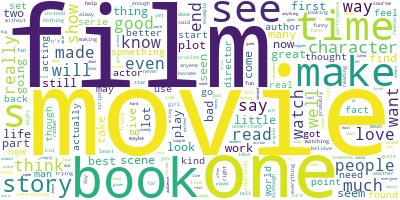

In [12]:
long_string = ','.join(list(training_data_topic['review_processed'].values))

wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')

wordcloud.generate(long_string)

wordcloud.to_image()

/var/folders/lc/kpr2rnx93q52qglqhvd6c6vw0000gn/T/ipykernel_79064/2938581420.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_pos, y=counts, palette='husl')


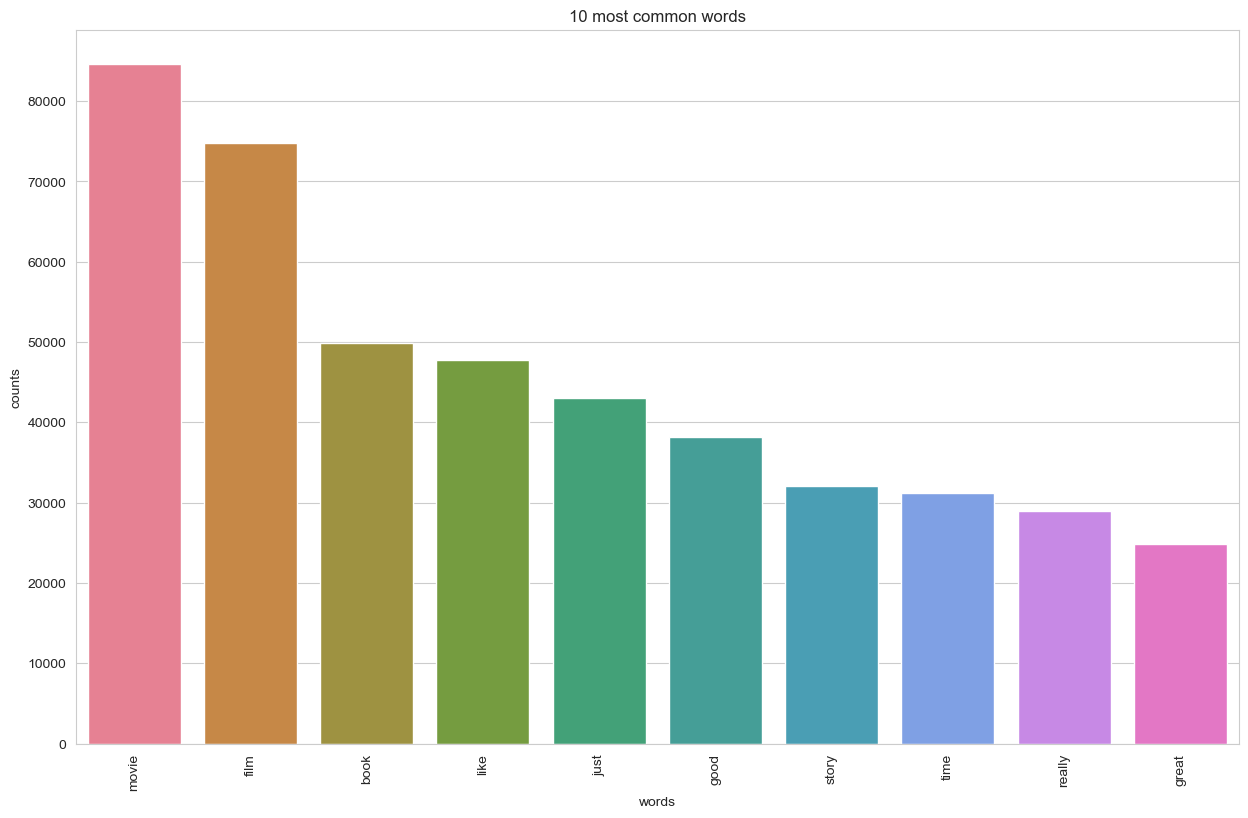

In [13]:
sns.set_style('whitegrid')
%matplotlib inline

# Helper function
def plot_10_most_common_words(count_data, count_vectorizer):
    words = count_vectorizer.get_feature_names_out()
    total_counts = np.zeros(len(words))
    for t in count_data:
        total_counts+=t.toarray()[0]
    
    count_dict = (zip(words, total_counts))
    count_dict = sorted(count_dict, key=lambda x:x[1], reverse=True)[0:10]
    words = [w[0] for w in count_dict]
    counts = [w[1] for w in count_dict]
    x_pos = np.arange(len(words)) 
    
    plt.figure(2, figsize=(15, 15/1.6180))
    plt.subplot(title='10 most common words')
    sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})
    sns.barplot(x=x_pos, y=counts, palette='husl')
    plt.xticks(x_pos, words, rotation=90) 
    plt.xlabel('words')
    plt.ylabel('counts')
    plt.show()

# Initialise the count vectorizer with the English stop words
count_vectorizer = CountVectorizer(stop_words='english')

# Fit and transform the processed titles
count_data = count_vectorizer.fit_transform(training_data_topic['review_processed'])

# Visualise the 10 most common words
plot_10_most_common_words(count_data, count_vectorizer)

## Model for topic classification

In [14]:
max_samples = 10000

train = train.groupby('labels', group_keys=False).apply(lambda x: x.sample(n=min(len(x), max_samples), random_state=42))

print(train['labels'].value_counts())

labels
book      10000
movie     10000
sports    10000
Name: count, dtype: int64


/var/folders/lc/kpr2rnx93q52qglqhvd6c6vw0000gn/T/ipykernel_79064/3045598224.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = train.groupby('labels', group_keys=False).apply(lambda x: x.sample(n=min(len(x), max_samples), random_state=42))


In [15]:
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0, 
                               stratify=train[['labels']])

In [16]:
train['labels'] = train['labels'].astype('category')
dev['labels'] = dev['labels'].astype('category')
train['text'] = train['text'].str.strip()
dev['text'] = dev['text'].str.strip()

train['labels'] = train['labels'].str.strip()
dev['labels'] = dev['labels'].str.strip()


In [17]:
from sklearn.preprocessing import LabelEncoder

# Convert labels to integer format
label_encoder = LabelEncoder()

train['labels'] = label_encoder.fit_transform(train['labels'])
dev['labels'] = label_encoder.transform(dev['labels'])

print(train.head())

                                                     text  labels
104792  baku : david beckham is set to be hauled over ...       2
12766                                              go slu       0
9880    a more accurate title for this book would be “...       0
77921   i saw two hands back in sydney a few years ago...       1
103179  the first two at-bats were the kind of moments...       2


In [18]:
# Flatten any potential multi-dimensional array (if present)
train['labels'] = train['labels'].apply(lambda x: x[0] if isinstance(x, list) else x)
dev['labels'] = dev['labels'].apply(lambda x: x[0] if isinstance(x, list) else x)

print(train.head())


                                                     text  labels
104792  baku : david beckham is set to be hauled over ...       2
12766                                              go slu       0
9880    a more accurate title for this book would be “...       0
77921   i saw two hands back in sydney a few years ago...       1
103179  the first two at-bats were the kind of moments...       2


In [19]:
print(len(train))
print("train:", train[['labels']].value_counts(sort=False))
print(train.head(3))
print(type(train))

27000
train: labels
0         9000
1         9000
2         9000
Name: count, dtype: int64
                                                     text  labels
104792  baku : david beckham is set to be hauled over ...       2
12766                                              go slu       0
9880    a more accurate title for this book would be “...       0
<class 'pandas.core.frame.DataFrame'>


In [20]:
print(len(dev))
print("dev:", dev[['labels']].value_counts(sort=False))
print(dev.head(3))
print(type(dev))

3000
dev: labels
0         1000
1         1000
2         1000
Name: count, dtype: int64
                                                     text  labels
29094   i'm sorry- no offense meant to the writer- but...       0
45019   nick millard aka nick phillips should have lef...       1
106052  ap - rich gannon will not return to the field ...       2
<class 'pandas.core.frame.DataFrame'>


In [26]:
# Model configuration
bert_args = ClassificationArgs()

bert_args.overwrite_output_dir=True
bert_args.evaluate_during_training=True

bert_args.num_train_epochs=10
bert_args.train_batch_size=32
bert_args.gradient_accumulation_steps = 4
bert_args.learning_rate=5e-5
bert_args.max_seq_length=256

bert_args.warmup_ratio=0.1

bert_args.use_early_stopping=True
bert_args.early_stopping_delta=0.01

bert_args.early_stopping_metric='eval_loss'
bert_args.early_stopping_metric_minimize=True
bert_args.early_stopping_patience=8
bert_args.evaluate_during_training_steps=32

# Model configuration based off of paper: Sun-etal-2020-Fine tuning BERT for Text Classification (pages 4 'Hyperparameters', page 5 'Catastrophic Forgetting')
# and due to the needs of the training data labeled as big_data.csv

In [27]:
steps_per_epoch = int(np.ceil(len(train) / float(bert_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch)) # 64 steps = validating 2 times per epoch

Each epoch will have 844 steps.


In [28]:
model = ClassificationModel('bert', 'bert-base-cased', num_labels=3, args=bert_args, use_cuda=False)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
print(str(model.args).replace(',', '\n'))

ClassificationArgs(adafactor_beta1=None
 adafactor_clip_threshold=1.0
 adafactor_decay_rate=-0.8
 adafactor_eps=(1e-30
 0.001)
 adafactor_relative_step=True
 adafactor_scale_parameter=True
 adafactor_warmup_init=True
 adam_betas=(0.9
 0.999)
 adam_epsilon=1e-08
 best_model_dir='outputs/best_model'
 cache_dir='cache_dir/'
 config={}
 cosine_schedule_num_cycles=0.5
 custom_layer_parameters=[]
 custom_parameter_groups=[]
 dataloader_num_workers=0
 do_lower_case=False
 dynamic_quantize=False
 early_stopping_consider_epochs=False
 early_stopping_delta=0.01
 early_stopping_metric='eval_loss'
 early_stopping_metric_minimize=True
 early_stopping_patience=8
 encoding=None
 eval_batch_size=100
 evaluate_during_training=True
 evaluate_during_training_silent=True
 evaluate_during_training_steps=32
 evaluate_during_training_verbose=False
 evaluate_each_epoch=True
 fp16=False
 gradient_accumulation_steps=4
 learning_rate=5e-05
 local_rank=-1
 logging_steps=50
 loss_type=None
 loss_args={}
 manual_se

In [30]:
_, history = model.train_model(train, eval_df=dev) 

  0%|          | 0/54 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Running Epoch 1 of 10:   0%|          | 0/844 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable To disable this warning, you can either:
	- Avoid using `

Running Epoch 3 of 10:   0%|          | 0/844 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

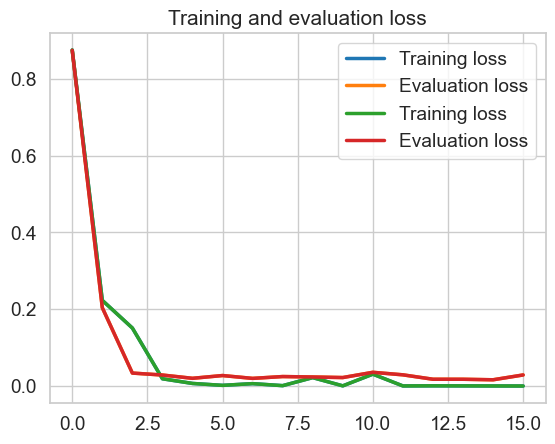

In [46]:
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()
plt.show()

In [32]:
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

  0%|          | 0/6 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Running Evaluation:   0%|          | 0/30 [00:00<?, ?it/s]

{'mcc': np.float64(0.9895051124562882), 'eval_loss': 0.02902314242965076}

In [33]:
predicted, probabilities = model.predict(test.text.to_list())
test['predicted'] = predicted

0it [00:00, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  0%|          | 0/1 [00:00<?, ?it/s]

In [56]:
test['predicted'] = label_encoder.inverse_transform(test['predicted'])

ValueError: y contains previously unseen labels: ['book' 'movie' 'sports']

In [57]:
print(test.head(5))

                                                text  labels predicted
0  the atmosphere at the stadium tonight was elec...  sports    sports
1  the game was so intense i forgot to breathe at...  sports      book
2           it had me hooked from the first chapter.    book      book
3  it’s more of a slow burn than a page-turner, b...    book      book
4  it’s split into two timelines, which keeps it ...    book      book


In [58]:
print(train['labels'].dtype)
print(train['labels'].unique())

object
['sports' 'book' 'movie']


In [61]:
print(classification_report(test['labels'], test['predicted']))

              precision    recall  f1-score   support

        book       0.45      0.83      0.59         6
       movie       1.00      0.17      0.29         6
      sports       0.83      0.83      0.83         6

    accuracy                           0.61        18
   macro avg       0.76      0.61      0.57        18
weighted avg       0.76      0.61      0.57        18

